<a href="https://colab.research.google.com/github/ArulKingsley/SmartQuant/blob/naveen-dev/notebooks/SMQuant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
df = yf.download("AAPL", start="2018-01-01", end="2023-01-01")

/tmp/ipython-input-3180308820.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2018-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1259 entries, 2018-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1259 non-null   float64
 1   (High, AAPL)    1259 non-null   float64
 2   (Low, AAPL)     1259 non-null   float64
 3   (Open, AAPL)    1259 non-null   float64
 4   (Volume, AAPL)  1259 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [3]:
!pip install pandas_ta ta

  Using cached numpy-2.3.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.2 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.2 which is incompatible.


In [4]:
import pandas_ta as ta
import pandas as pd


df['RSI'] = ta.rsi(df['Close'], length=14)

In [5]:
print(df.head())

Price           Close       High        Low       Open     Volume   RSI
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL      
Date                                                                   
2018-01-02  40.381001  40.390379  39.677744  39.888723  102223600  None
2018-01-03  40.373959  40.917812  40.310668  40.444285  118071600  None
2018-01-04  40.561501  40.664645  40.338803  40.446634   89738400  None
2018-01-05  41.023304  41.110038  40.566188  40.657611   94640000  None
2018-01-08  40.870930  41.166296  40.772471  40.870930   82271200  None


In [6]:
sum(df["RSI"].value_counts())

0

In [7]:
print(df['Close'].head())
#print(df[['Close']].dtype)

Ticker           AAPL
Date                 
2018-01-02  40.381001
2018-01-03  40.373959
2018-01-04  40.561501
2018-01-05  41.023304
2018-01-08  40.870930


In [8]:
df.columns = df.columns.get_level_values(0)

In [9]:
df.head()

Price,Close,High,Low,Open,Volume,RSI
Date,,,,,,
2018-01-02,40.381001,40.390379,39.677744,39.888723,102223600,None
2018-01-03,40.373959,40.917812,40.310668,40.444285,118071600,None
2018-01-04,40.561501,40.664645,40.338803,40.446634,89738400,None
2018-01-05,41.023304,41.110038,40.566188,40.657611,94640000,None
2018-01-08,40.870930,41.166296,40.772471,40.870930,82271200,None


In [10]:
df['RSI'] = ta.rsi(close=df['Close'], length=14)

In [11]:
print(df["RSI"].head())

Date
2018-01-02          NaN
2018-01-03     0.000000
2018-01-04    67.198371
2018-01-05    88.209238
2018-01-08    71.854558
Name: RSI, dtype: float64


In [12]:
macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
df = pd.concat([df, macd], axis=1)

aroon = ta.aroon(df['High'], df['Low'], length=14)
df = pd.concat([df, aroon], axis=1)

bbands = ta.bbands(df['Close'], length=20, std=2)
df = pd.concat([df, bbands], axis=1)

In [13]:
df.head()

,Close,High,Low,Open,Volume,RSI,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,AROOND_14,AROONU_14,AROONOSC_14,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0
Date,,,,,,,,,,,,,,,,,
2018-01-02,40.381001,40.390379,39.677744,39.888723,102223600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,40.373959,40.917812,40.310668,40.444285,118071600,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,40.561501,40.664645,40.338803,40.446634,89738400,67.198371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,41.023304,41.110038,40.566188,40.657611,94640000,88.209238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,40.870930,41.166296,40.772471,40.870930,82271200,71.854558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
sum(df["MACD_12_26_9"].value_counts())

1234

In [15]:
sum(df["AROOND_14"].value_counts())

1245

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1259 entries, 2018-01-02 to 2022-12-30
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Close           1259 non-null   float64
 1   High            1259 non-null   float64
 2   Low             1259 non-null   float64
 3   Open            1259 non-null   float64
 4   Volume          1259 non-null   int64  
 5   RSI             1258 non-null   float64
 6   MACD_12_26_9    1234 non-null   float64
 7   MACDh_12_26_9   1226 non-null   float64
 8   MACDs_12_26_9   1226 non-null   float64
 9   AROOND_14       1245 non-null   float64
 10  AROONU_14       1245 non-null   float64
 11  AROONOSC_14     1245 non-null   float64
 12  BBL_20_2.0_2.0  1240 non-null   float64
 13  BBM_20_2.0_2.0  1240 non-null   float64
 14  BBU_20_2.0_2.0  1240 non-null   float64
 15  BBB_20_2.0_2.0  1240 non-null   float64
 16  BBP_20_2.0_2.0  1240 non-null   float64
dtypes: float64(16),

In [17]:
df = df.dropna()


In [18]:
print(df.head())

                Close       High        Low       Open     Volume        RSI  \
Date                                                                           
2018-02-20  40.449131  41.016381  40.347918  40.496205  135722000  56.628624   
2018-02-21  40.265537  40.983427  40.251412  40.679795  149886400  55.253557   
2018-02-22  40.602127  40.943420  40.416183  40.437366  123967600  57.300647   
2018-02-23  41.308262  41.343567  40.846926  40.877526  135249600  61.300592   
2018-02-26  42.124989  42.223845  41.475356  41.508308  152648800  65.344312   

            MACD_12_26_9  MACDh_12_26_9  MACDs_12_26_9  AROOND_14   AROONU_14  \
Date                                                                            
2018-02-20     -0.449676       0.652050      -1.101725  57.142857   92.857143   
2018-02-21     -0.338712       0.610411      -0.949123  50.000000   85.714286   
2018-02-22     -0.221064       0.582447      -0.803511  42.857143   78.571429   
2018-02-23     -0.070040       0.5

In [19]:
!pip install --upgrade --force-reinstall numpy==1.26.4
!pip install --upgrade scikit-learn pandas-ta

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-ta 0.4.67b0 requires numpy>=2.2.6, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.2 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.2 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9",

In [20]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd


# Create a copy of df to scale
df_clean = df.dropna().copy()

# Initialize scaler
scaler = MinMaxScaler()

# Fit and transform all columns
scaled = scaler.fit_transform(df_clean)

# Back to DataFrame with same column names
df_scaled = pd.DataFrame(scaled, index=df_clean.index, columns=df_clean.columns)

df_scaled.head()

,Close,High,Low,Open,Volume,RSI,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,AROOND_14,AROONU_14,AROONOSC_14,BBL_20_2.0_2.0,BBM_20_2.0_2.0,BBU_20_2.0_2.0,BBB_20_2.0_2.0,BBP_20_2.0_2.0
Date,,,,,,,,,,,,,,,,,
2018-02-20,0.045755,0.043848,0.046260,0.043081,0.256894,0.536252,0.436987,0.648728,0.367397,0.571429,0.928571,0.678571,0.018703,0.019774,0.025998,0.367769,0.611136
2018-02-21,0.044486,0.043620,0.045579,0.044349,0.293091,0.514335,0.445008,0.640015,0.379700,0.500000,0.857143,0.678571,0.019485,0.019321,0.024421,0.342711,0.606342
2018-02-22,0.046813,0.043343,0.046741,0.042675,0.226855,0.546963,0.453512,0.634164,0.391440,0.428571,0.785714,0.678571,0.019628,0.019234,0.024125,0.338044,0.645607
2018-02-23,0.051696,0.046109,0.049778,0.045715,0.255686,0.610716,0.464428,0.635070,0.403267,0.357143,1.000000,0.821429,0.018959,0.019672,0.025569,0.360484,0.703280
2018-02-26,0.057344,0.052193,0.054209,0.050071,0.300150,0.675167,0.477748,0.641360,0.415700,0.285714,1.000000,0.857143,0.017638,0.020375,0.028115,0.401461,0.751591


In [21]:
print(df_scaled.head())

               Close      High       Low      Open    Volume       RSI  \
Date                                                                     
2018-02-20  0.045755  0.043848  0.046260  0.043081  0.256894  0.536252   
2018-02-21  0.044486  0.043620  0.045579  0.044349  0.293091  0.514335   
2018-02-22  0.046813  0.043343  0.046741  0.042675  0.226855  0.546963   
2018-02-23  0.051696  0.046109  0.049778  0.045715  0.255686  0.610716   
2018-02-26  0.057344  0.052193  0.054209  0.050071  0.300150  0.675167   

            MACD_12_26_9  MACDh_12_26_9  MACDs_12_26_9  AROOND_14  AROONU_14  \
Date                                                                           
2018-02-20      0.436987       0.648728       0.367397   0.571429   0.928571   
2018-02-21      0.445008       0.640015       0.379700   0.500000   0.857143   
2018-02-22      0.453512       0.634164       0.391440   0.428571   0.785714   
2018-02-23      0.464428       0.635070       0.403267   0.357143   1.000000   
2

## PHASE 2

In [22]:
import numpy as np

def create_sequences(data, target_col="Close", lookback=60):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)

    for i in range(lookback, len(data)):
        X.append(data.iloc[i-lookback:i].values)   # 60 days history
        y.append(data.iloc[i, target_idx])        # next day close

    return np.array(X), np.array(y)

# Using df_scaled from Phase 1
X, y = create_sequences(df_scaled, target_col="Close", lookback=60)

print("X shape:", X.shape)  # (samples, lookback, features)
print("y shape:", y.shape)  # (samples,)

X shape: (1166, 60, 17)
y shape: (1166,)


In [23]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Train samples: 932
Test samples: 234


In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # predict next-day close
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,129 (219.25 KB)

 Trainable params: 56,129 (219.25 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - loss: 0.1011 - val_loss: 0.0072
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.0057 - val_loss: 0.0128
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0044 - val_loss: 0.0079
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0037 - val_loss: 0.0045
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0030 - val_loss: 0.0037
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0026 - val_loss: 0.0107
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0029 - val_loss: 0.0077
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0021 - val_loss: 0.0073
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0023 - val_loss: 0.0084
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0024 - val_loss: 0.0109
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step


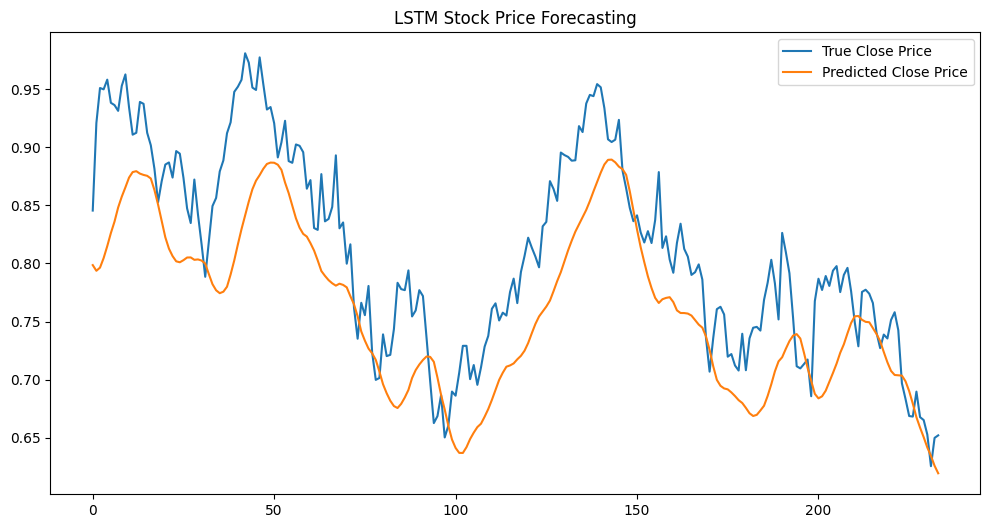

In [26]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

plt.figure(figsize=(12,6))
plt.plot(y_test, label="True Close Price")
plt.plot(y_pred, label="Predicted Close Price")
plt.legend()
plt.title("LSTM Stock Price Forecasting")
plt.show()